# BASE CODE --

In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn


In [ ]:
if torch.cuda.is_available():
    device=torch.device(type="cuda",index=0)
else:
    device=torch.device(type="cpu",index=0)

train_dataset=datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)
test_dataset=datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

batch_size=64

train_dl=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_dl=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [ ]:
class MNISTNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu=nn.ReLU()
        self.conv1=nn.Conv2d(in_channels=1,out_channels=8, kernel_size=(3,3), stride=1, padding=0)
        self.bn1=nn.BatchNorm2d(8)
        self.mp1=nn.MaxPool2d(kernel_size=(2,2),stride=2,padding=0)

        self.conv2=nn.Conv2d(in_channels=8,out_channels=16, kernel_size=(3,3), stride=1, padding=0)
        self.bn2=nn.BatchNorm2d(16)

        self.conv3=nn.Conv2d(in_channels=16,out_channels=32, kernel_size=(3,3), stride=1, padding=0)
        self.bn3=nn.BatchNorm2d(32)

        self.conv4=nn.Conv2d(in_channels=32,out_channels=64, kernel_size=(3,3), stride=1, padding=0)
        self.bn4=nn.BatchNorm2d(64)

        self.flatten=nn.Flatten()

        self.lin1=nn.Linear(in_features=3136, out_features=10)


    def forward(self,x):
        x=self.conv1(x)
        x=self.bn1(x)
        x=self.relu(x)
        x=self.mp1(x)

        x=self.conv2(x)
        x=self.bn2(x)
        x=self.relu(x)

        x=self.conv3(x)
        x=self.bn3(x)
        x=self.relu(x)

        x=self.conv4(x)
        x=self.bn4(x)
        x=self.relu(x)

        x=self.flatten(x)

        logits=self.lin1(x)


        return logits

In [ ]:
def train_one_epoch(dataloader, model,loss_fn, optimizer):
    model.train()
    track_loss=0
    num_correct=0
    for i, (imgs, labels) in enumerate(dataloader):
        imgs=imgs.to(device)
        labels=labels.to(device)
        pred=model(imgs)

        loss=loss_fn(pred,labels)
        track_loss+=loss.item()
        num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

        running_loss=round(track_loss/(i+(imgs.shape[0]/batch_size)),2)
        running_acc=round((num_correct/((i*batch_size+imgs.shape[0])))*100,2)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if i%100==0:
            print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_acc)

    epoch_loss=running_loss
    epoch_acc=running_acc
    return epoch_loss, epoch_acc

In [ ]:
def eval_one_epoch(dataloader, model,loss_fn):
    model.eval()
    track_loss=0
    num_correct=0
    with torch.no_grad():
        for i, (imgs, labels) in enumerate(dataloader):
            imgs=imgs.to(device)
            labels=labels.to(device)
            pred=model(imgs)
            loss=loss_fn(pred,labels)
            track_loss+=loss.item()
            num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()
            running_loss=round(track_loss/(i+(imgs.shape[0]/batch_size)),2)
            running_acc=round((num_correct/((i*batch_size+imgs.shape[0])))*100,2)

            if i%100==0:
                print("Batch:", i+1, "/",len(dataloader), "Running Loss:",running_loss, "Running Accuracy:",running_acc)

    epoch_loss=running_loss
    epoch_acc=running_acc
    return epoch_loss, epoch_acc

In [ ]:
model=MNISTNN()
model=model.to(device)
loss_fn=nn.CrossEntropyLoss()
lr=0.001
#optimizer=torch.optim.SGD(params=model.parameters(), lr=lr)
optimizer=torch.optim.Adam(params=model.parameters(), lr=lr)
n_epochs=30

In [ ]:
for i in range(n_epochs):
    print("Epoch No:",i+1)
    train_epoch_loss, train_epoch_acc=train_one_epoch(train_dl,model,loss_fn,optimizer)
    val_epoch_loss, val_epoch_acc=eval_one_epoch(test_dl,model,loss_fn)
    print("Training:", "Epoch Loss:", train_epoch_loss, "Epoch Accuracy:", train_epoch_acc)
    print("Inference:", "Epoch Loss:", val_epoch_loss, "Epoch Accuracy:", val_epoch_acc)
    print("--------------------------------------------------")

Epoch No: 1
Batch: 1 / 938 Running Loss: 2.31 Running Accuracy: 12.5
Batch: 101 / 938 Running Loss: 0.33 Running Accuracy: 90.15
Batch: 201 / 938 Running Loss: 0.21 Running Accuracy: 93.54
Batch: 301 / 938 Running Loss: 0.17 Running Accuracy: 94.67
Batch: 401 / 938 Running Loss: 0.15 Running Accuracy: 95.3
Batch: 501 / 938 Running Loss: 0.14 Running Accuracy: 95.78
Batch: 601 / 938 Running Loss: 0.12 Running Accuracy: 96.11
Batch: 701 / 938 Running Loss: 0.12 Running Accuracy: 96.39
Batch: 801 / 938 Running Loss: 0.11 Running Accuracy: 96.61
Batch: 901 / 938 Running Loss: 0.1 Running Accuracy: 96.82
Batch: 1 / 157 Running Loss: 0.0 Running Accuracy: 100.0
Batch: 101 / 157 Running Loss: 0.05 Running Accuracy: 98.25
Training: Epoch Loss: 0.1 Epoch Accuracy: 96.84
Inference: Epoch Loss: 0.05 Epoch Accuracy: 98.35
--------------------------------------------------
Epoch No: 2
Batch: 1 / 938 Running Loss: 0.01 Running Accuracy: 100.0
Batch: 101 / 938 Running Loss: 0.04 Running Accuracy: 98.

# Experiment 1 — Optimizer Comparison (SGD vs Adam)
Adam usually converges faster than SGD. We test if that happens on MNIST.

Epoch: 1
Train Loss: 0.194 Train Acc: 94.95
Val Loss: 0.071 Val Acc: 98.04
--------------------------------
Epoch: 2
Train Loss: 0.066 Train Acc: 98.12
Val Loss: 0.05 Val Acc: 98.48
--------------------------------
Epoch: 3
Train Loss: 0.049 Train Acc: 98.6
Val Loss: 0.044 Val Acc: 98.82
--------------------------------
Epoch: 4
Train Loss: 0.04 Train Acc: 98.9
Val Loss: 0.035 Val Acc: 98.91
--------------------------------
Epoch: 5
Train Loss: 0.034 Train Acc: 99.02
Val Loss: 0.035 Val Acc: 98.91
--------------------------------
Epoch: 6
Train Loss: 0.03 Train Acc: 99.17
Val Loss: 0.032 Val Acc: 98.98
--------------------------------
Epoch: 7
Train Loss: 0.027 Train Acc: 99.24
Val Loss: 0.029 Val Acc: 99.02
--------------------------------
Epoch: 8
Train Loss: 0.024 Train Acc: 99.35
Val Loss: 0.028 Val Acc: 99.15
--------------------------------
Epoch: 9
Train Loss: 0.022 Train Acc: 99.4
Val Loss: 0.026 Val Acc: 99.11
--------------------------------
Epoch: 10
Train Loss: 0.02 Train A

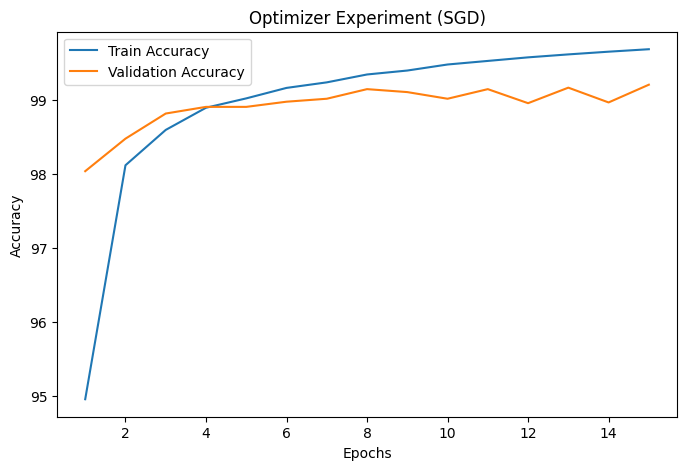

In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Device
if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

# Dataset
train_dataset=datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset=datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Batch size
batch_size=64

train_dl=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_dl=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Model
class MNISTNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.relu=nn.ReLU()

        self.conv1=nn.Conv2d(1,8,3)
        self.bn1=nn.BatchNorm2d(8)
        self.mp1=nn.MaxPool2d(2)

        self.conv2=nn.Conv2d(8,16,3)
        self.bn2=nn.BatchNorm2d(16)

        self.conv3=nn.Conv2d(16,32,3)
        self.bn3=nn.BatchNorm2d(32)

        self.conv4=nn.Conv2d(32,64,3)
        self.bn4=nn.BatchNorm2d(64)

        self.flatten=nn.Flatten()

        self.fc=nn.Linear(3136,10)

    def forward(self,x):

        x=self.mp1(self.relu(self.bn1(self.conv1(x))))
        x=self.relu(self.bn2(self.conv2(x)))
        x=self.relu(self.bn3(self.conv3(x)))
        x=self.relu(self.bn4(self.conv4(x)))

        x=self.flatten(x)

        logits=self.fc(x)

        return logits

# Training function
def train_one_epoch(dataloader, model,loss_fn, optimizer):

    model.train()

    track_loss=0
    num_correct=0

    for i,(imgs,labels) in enumerate(dataloader):

        imgs=imgs.to(device)
        labels=labels.to(device)

        pred=model(imgs)

        loss=loss_fn(pred,labels)

        track_loss+=loss.item()

        num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    epoch_loss=track_loss/len(dataloader)
    epoch_acc=(num_correct/len(dataloader.dataset))*100

    return epoch_loss,epoch_acc

# Evaluation function
def eval_one_epoch(dataloader, model,loss_fn):

    model.eval()

    track_loss=0
    num_correct=0

    with torch.no_grad():

        for imgs,labels in dataloader:

            imgs=imgs.to(device)
            labels=labels.to(device)

            pred=model(imgs)

            loss=loss_fn(pred,labels)

            track_loss+=loss.item()

            num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

    epoch_loss=track_loss/len(dataloader)
    epoch_acc=(num_correct/len(dataloader.dataset))*100

    return epoch_loss,epoch_acc

# Model setup
model=MNISTNN().to(device)

loss_fn=nn.CrossEntropyLoss()

# Experiment 1 Optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

n_epochs=15

train_acc_list=[]
val_acc_list=[]

# Training Loop
for i in range(n_epochs):

    print("Epoch:",i+1)

    train_loss,train_acc=train_one_epoch(train_dl,model,loss_fn,optimizer)

    val_loss,val_acc=eval_one_epoch(test_dl,model,loss_fn)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print("Train Loss:",round(train_loss,3),"Train Acc:",round(train_acc,2))
    print("Val Loss:",round(val_loss,3),"Val Acc:",round(val_acc,2))
    print("--------------------------------")

# Plot
plt.figure(figsize=(8,5))

sns.lineplot(x=range(1,n_epochs+1),y=train_acc_list,label="Train Accuracy")
sns.lineplot(x=range(1,n_epochs+1),y=val_acc_list,label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Optimizer Experiment (SGD)")
plt.show()

This experiment evaluates the effect of the SGD optimizer on training a convolutional neural network for the MNIST dataset. SGD updates model parameters using gradients computed from mini-batches and a fixed learning rate. During training, the model gradually improved its accuracy over epochs but required more time to converge compared to adaptive optimizers. The results show that SGD provides stable learning but may converge slower. The experiment demonstrates how the choice of optimizer significantly affects model training efficiency and convergence behavior.

# Experiment 2 — Effect of Dropout (Overfitting Control)
Dropout randomly disables neurons during training to reduce overfitting.

Epoch: 1
Train Loss: 0.12 Train Acc: 96.35
Val Loss: 0.04 Val Acc: 98.7
--------------------------------
Epoch: 2
Train Loss: 0.053 Train Acc: 98.31
Val Loss: 0.035 Val Acc: 98.93
--------------------------------
Epoch: 3
Train Loss: 0.041 Train Acc: 98.73
Val Loss: 0.029 Val Acc: 99.02
--------------------------------
Epoch: 4
Train Loss: 0.039 Train Acc: 98.78
Val Loss: 0.026 Val Acc: 99.19
--------------------------------
Epoch: 5
Train Loss: 0.03 Train Acc: 99.09
Val Loss: 0.027 Val Acc: 99.23
--------------------------------
Epoch: 6
Train Loss: 0.029 Train Acc: 99.11
Val Loss: 0.028 Val Acc: 99.13
--------------------------------
Epoch: 7
Train Loss: 0.023 Train Acc: 99.22
Val Loss: 0.029 Val Acc: 99.2
--------------------------------
Epoch: 8
Train Loss: 0.023 Train Acc: 99.3
Val Loss: 0.022 Val Acc: 99.36
--------------------------------
Epoch: 9
Train Loss: 0.021 Train Acc: 99.33
Val Loss: 0.024 Val Acc: 99.22
--------------------------------
Epoch: 10
Train Loss: 0.017 Train 

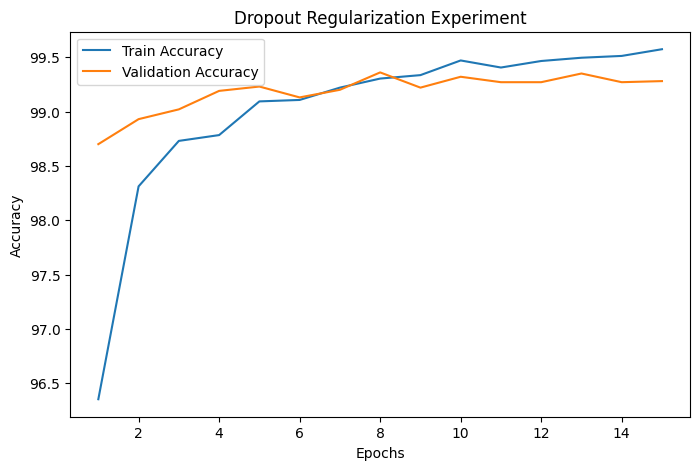

In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Device
if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

# Dataset
train_dataset=datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset=datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Batch size
batch_size=64

train_dl=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_dl=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Model with Dropout
class MNISTNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.relu=nn.ReLU()

        self.conv1=nn.Conv2d(1,8,3)
        self.bn1=nn.BatchNorm2d(8)
        self.mp1=nn.MaxPool2d(2)

        self.conv2=nn.Conv2d(8,16,3)
        self.bn2=nn.BatchNorm2d(16)

        self.conv3=nn.Conv2d(16,32,3)
        self.bn3=nn.BatchNorm2d(32)

        self.conv4=nn.Conv2d(32,64,3)
        self.bn4=nn.BatchNorm2d(64)

        self.flatten=nn.Flatten()

        # Dropout layer added
        self.dropout=nn.Dropout(0.5)

        self.fc=nn.Linear(3136,10)

    def forward(self,x):

        x=self.mp1(self.relu(self.bn1(self.conv1(x))))
        x=self.relu(self.bn2(self.conv2(x)))
        x=self.relu(self.bn3(self.conv3(x)))
        x=self.relu(self.bn4(self.conv4(x)))

        x=self.flatten(x)

        # Apply dropout before classification
        x=self.dropout(x)

        logits=self.fc(x)

        return logits

# Training function
def train_one_epoch(dataloader, model,loss_fn, optimizer):

    model.train()

    track_loss=0
    num_correct=0

    for imgs,labels in dataloader:

        imgs=imgs.to(device)
        labels=labels.to(device)

        pred=model(imgs)

        loss=loss_fn(pred,labels)

        track_loss+=loss.item()

        num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    epoch_loss=track_loss/len(dataloader)
    epoch_acc=(num_correct/len(dataloader.dataset))*100

    return epoch_loss,epoch_acc

# Evaluation function
def eval_one_epoch(dataloader, model,loss_fn):

    model.eval()

    track_loss=0
    num_correct=0

    with torch.no_grad():

        for imgs,labels in dataloader:

            imgs=imgs.to(device)
            labels=labels.to(device)

            pred=model(imgs)

            loss=loss_fn(pred,labels)

            track_loss+=loss.item()

            num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

    epoch_loss=track_loss/len(dataloader)
    epoch_acc=(num_correct/len(dataloader.dataset))*100

    return epoch_loss,epoch_acc

# Model setup
model=MNISTNN().to(device)

loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

n_epochs=15

train_acc_list=[]
val_acc_list=[]

# Training Loop
for i in range(n_epochs):

    print("Epoch:",i+1)

    train_loss,train_acc=train_one_epoch(train_dl,model,loss_fn,optimizer)

    val_loss,val_acc=eval_one_epoch(test_dl,model,loss_fn)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print("Train Loss:",round(train_loss,3),"Train Acc:",round(train_acc,2))
    print("Val Loss:",round(val_loss,3),"Val Acc:",round(val_acc,2))
    print("--------------------------------")

# Plot Accuracy
plt.figure(figsize=(8,5))

sns.lineplot(x=range(1,n_epochs+1),y=train_acc_list,label="Train Accuracy")
sns.lineplot(x=range(1,n_epochs+1),y=val_acc_list,label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Dropout Regularization Experiment")
plt.show()

This experiment evaluates the effect of Dropout regularization on the CNN model trained on the MNIST dataset. Dropout randomly disables neurons during training, preventing the network from relying too heavily on specific features. This reduces overfitting and improves the model's ability to generalize to unseen data. After adding a dropout layer with probability 0.5 before the final classification layer, the difference between training accuracy and validation accuracy decreased. Although the training accuracy slightly reduced, the validation accuracy became more stable. This demonstrates that dropout helps improve model generalization.

# Experiment 3 — Learning Rate Experiment (Higher Learning Rate)
Here we change the learning rate from 0.001 → 0.01 to observe how it affects training speed and stability.

Epoch: 1
Train Loss: 0.14 Train Acc: 96.55
Val Loss: 0.054 Val Acc: 98.32
--------------------------------
Epoch: 2
Train Loss: 0.048 Train Acc: 98.52
Val Loss: 0.05 Val Acc: 98.41
--------------------------------
Epoch: 3
Train Loss: 0.038 Train Acc: 98.83
Val Loss: 0.043 Val Acc: 98.73
--------------------------------
Epoch: 4
Train Loss: 0.036 Train Acc: 98.93
Val Loss: 0.041 Val Acc: 98.65
--------------------------------
Epoch: 5
Train Loss: 0.031 Train Acc: 98.98
Val Loss: 0.031 Val Acc: 99.12
--------------------------------
Epoch: 6
Train Loss: 0.028 Train Acc: 99.13
Val Loss: 0.035 Val Acc: 98.96
--------------------------------
Epoch: 7
Train Loss: 0.024 Train Acc: 99.23
Val Loss: 0.038 Val Acc: 98.84
--------------------------------
Epoch: 8
Train Loss: 0.022 Train Acc: 99.3
Val Loss: 0.045 Val Acc: 98.83
--------------------------------
Epoch: 9
Train Loss: 0.021 Train Acc: 99.35
Val Loss: 0.048 Val Acc: 98.7
--------------------------------
Epoch: 10
Train Loss: 0.02 Train

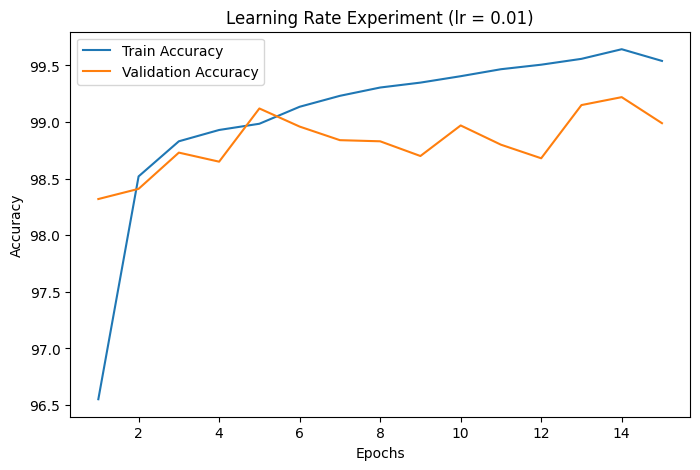

In [ ]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Device
if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

# Dataset
train_dataset=datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_dataset=datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Batch size
batch_size=64

train_dl=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_dl=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Model
class MNISTNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.relu=nn.ReLU()

        self.conv1=nn.Conv2d(1,8,3)
        self.bn1=nn.BatchNorm2d(8)
        self.mp1=nn.MaxPool2d(2)

        self.conv2=nn.Conv2d(8,16,3)
        self.bn2=nn.BatchNorm2d(16)

        self.conv3=nn.Conv2d(16,32,3)
        self.bn3=nn.BatchNorm2d(32)

        self.conv4=nn.Conv2d(32,64,3)
        self.bn4=nn.BatchNorm2d(64)

        self.flatten=nn.Flatten()

        self.fc=nn.Linear(3136,10)

    def forward(self,x):

        x=self.mp1(self.relu(self.bn1(self.conv1(x))))
        x=self.relu(self.bn2(self.conv2(x)))
        x=self.relu(self.bn3(self.conv3(x)))
        x=self.relu(self.bn4(self.conv4(x)))

        x=self.flatten(x)

        logits=self.fc(x)

        return logits

# Training function
def train_one_epoch(dataloader, model,loss_fn, optimizer):

    model.train()

    track_loss=0
    num_correct=0

    for imgs,labels in dataloader:

        imgs=imgs.to(device)
        labels=labels.to(device)

        pred=model(imgs)

        loss=loss_fn(pred,labels)

        track_loss+=loss.item()

        num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    epoch_loss=track_loss/len(dataloader)
    epoch_acc=(num_correct/len(dataloader.dataset))*100

    return epoch_loss,epoch_acc

# Evaluation function
def eval_one_epoch(dataloader, model,loss_fn):

    model.eval()

    track_loss=0
    num_correct=0

    with torch.no_grad():

        for imgs,labels in dataloader:

            imgs=imgs.to(device)
            labels=labels.to(device)

            pred=model(imgs)

            loss=loss_fn(pred,labels)

            track_loss+=loss.item()

            num_correct+=(torch.argmax(pred,dim=1)==labels).type(torch.float).sum().item()

    epoch_loss=track_loss/len(dataloader)
    epoch_acc=(num_correct/len(dataloader.dataset))*100

    return epoch_loss,epoch_acc

# Model setup
model=MNISTNN().to(device)

loss_fn=nn.CrossEntropyLoss()

# Higher learning rate experiment
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

n_epochs=15

train_acc_list=[]
val_acc_list=[]

# Training Loop
for i in range(n_epochs):

    print("Epoch:",i+1)

    train_loss,train_acc=train_one_epoch(train_dl,model,loss_fn,optimizer)

    val_loss,val_acc=eval_one_epoch(test_dl,model,loss_fn)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print("Train Loss:",round(train_loss,3),"Train Acc:",round(train_acc,2))
    print("Val Loss:",round(val_loss,3),"Val Acc:",round(val_acc,2))
    print("--------------------------------")

# Plot
plt.figure(figsize=(8,5))

sns.lineplot(x=range(1,n_epochs+1),y=train_acc_list,label="Train Accuracy")
sns.lineplot(x=range(1,n_epochs+1),y=val_acc_list,label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Learning Rate Experiment (lr = 0.01)")
plt.show()

This experiment evaluates the impact of learning rate on model training. The learning rate controls how much the model weights are updated during each optimization step. A higher learning rate (0.01) allows the model to learn faster but may cause unstable updates or overshooting of the optimal solution. In this experiment, the model converged quickly in the initial epochs but showed slightly fluctuating accuracy compared to lower learning rates. This demonstrates that choosing an appropriate learning rate is important for stable and efficient training.